In [9]:
#to load data
import pandas as pd
df = pd.read_csv("C:/Users/salon/Downloads/CustomerSegmentationProject_MajorProject_SaloniRana/dataset/customer_transactions_1M.csv")
df.head()


,Transaction_ID,Customer_ID,Age,Region,Gender,Product_Category,Unit_Price,Quantity,Discount_Percent,Payment_Mode,Purchase_Date,Total_Amount,Final_Amount
0,1,25796,47,East,Female,Electronics,30885,1,5,Credit card,2025-03-18,30885,29340.75
1,2,10861,58,North,Male,Electronics,26692,1,25,Cash On Delivery,2024-09-03,26692,20019.00
2,3,48159,38,Central,Female,Home Decor,25487,1,28,UPI,2024-09-18,25487,18350.64
3,4,54733,42,North,Female,Fashion,1933,8,50,Debit Card,2024-02-14,15464,7732.00
4,5,21285,62,Central,Female,Electronics,18383,2,0,Cash On Delivery,2025-01-06,36766,36766.00


In [10]:
# to check how many rows and columns are present 
df.shape


(1000000, 13)

In [11]:
#for displaying first 5 rows
df.head()

,Transaction_ID,Customer_ID,Age,Region,Gender,Product_Category,Unit_Price,Quantity,Discount_Percent,Payment_Mode,Purchase_Date,Total_Amount,Final_Amount
0,1,25796,47,East,Female,Electronics,30885,1,5,Credit card,2025-03-18,30885,29340.75
1,2,10861,58,North,Male,Electronics,26692,1,25,Cash On Delivery,2024-09-03,26692,20019.00
2,3,48159,38,Central,Female,Home Decor,25487,1,28,UPI,2024-09-18,25487,18350.64
3,4,54733,42,North,Female,Fashion,1933,8,50,Debit Card,2024-02-14,15464,7732.00
4,5,21285,62,Central,Female,Electronics,18383,2,0,Cash On Delivery,2025-01-06,36766,36766.00


In [12]:
#to check data type and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Transaction_ID    1000000 non-null  int64  
 1   Customer_ID       1000000 non-null  int64  
 2   Age               1000000 non-null  int64  
 3   Region            1000000 non-null  str    
 4   Gender            1000000 non-null  str    
 5   Product_Category  1000000 non-null  str    
 6   Unit_Price        1000000 non-null  int64  
 7   Quantity          1000000 non-null  int64  
 8   Discount_Percent  1000000 non-null  int64  
 9   Payment_Mode      1000000 non-null  str    
 10  Purchase_Date     1000000 non-null  str    
 11  Total_Amount      1000000 non-null  int64  
 12  Final_Amount      1000000 non-null  float64
dtypes: float64(1), int64(7), str(5)
memory usage: 99.2 MB


In [13]:
#convert date in proper datetime format
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

In [14]:
#Reference date for finding latest date for finding recency
reference_date= df["Purchase_Date"].max() +pd.Timedelta(days=1)

In [15]:
# to create RFM table (Recency , Frequency Monetary)
#group data by Customer_id to analyze each customer separately
#calculate how many days ago the last purchase was made
rfm = df.groupby("Customer_ID").agg({
    "Purchase_Date" : lambda x : (reference_date - x.max()).days,
    "Transaction_ID" : "count" , 
    "Final_Amount" : "sum" 
})
#rename columns for better readability
rfm.columns = ["Recency" , "Frequency" , "Monetary"]
#display first few rows to verify
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
10001,158,12,933385.94
10002,69,20,1983418.76
10003,167,17,1515396.64
10004,73,30,2972122.18
10005,57,17,1819482.03


In [16]:
# Recency Score:
# Divide customers into 5 groups based on recency
# Lower recency (recent buyers) = higher score (5)
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])

# Frequency Score:
# More transactions = higher score
rfm["F_Score"] = pd.qcut(rfm["Frequency"], 5, labels=[1,2,3,4,5])

# Monetary Score:
# Higher spending = higher score
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

# Check scores
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer_ID,,,,,,
10001,158,12,933385.94,1,1,1
10002,69,20,1983418.76,2,3,3
10003,167,17,1515396.64,1,2,1
10004,73,30,2972122.18,2,5,5
10005,57,17,1819482.03,2,2,2


In [17]:
# Convert scores to string and combine
# Example: R=5, F=5, M=5 → "555"
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

# Check output
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer_ID,,,,,,,
10001,158,12,933385.94,1,1,1,111
10002,69,20,1983418.76,2,3,3,233
10003,167,17,1515396.64,1,2,1,121
10004,73,30,2972122.18,2,5,5,255
10005,57,17,1819482.03,2,2,2,222


In [18]:
# CUSTOMER SEGMENTATION
# Function to assign segment based on RFM scores
def segment(row):

    # Best customers: recent, frequent, high spenders
    if row["RFM_Score"] == "555":
        return "VIP"

    # Loyal customers: frequent + recent
    elif int(row["R_Score"]) >= 4 and int(row["F_Score"]) >= 4:
        return "Loyal"

    # New customers: recently joined
    elif int(row["R_Score"]) >= 4:
        return "New"

    # At Risk: used to buy frequently but not recently
    elif int(row["R_Score"]) <= 2 and int(row["F_Score"]) >= 4:
        return "At Risk"

    # Lost customers: inactive customers
    else:
        return "Lost"


# Apply segmentation function to each row
rfm["Segment"] = rfm.apply(segment, axis=1)

# Check result
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer_ID,,,,,,,,
10001,158,12,933385.94,1,1,1,111,Lost
10002,69,20,1983418.76,2,3,3,233,Lost
10003,167,17,1515396.64,1,2,1,121,Lost
10004,73,30,2972122.18,2,5,5,255,At Risk
10005,57,17,1819482.03,2,2,2,222,Lost


In [19]:
#SEGMENT DISTRIBUTION
# Count number of customers in each segment
segment_counts = rfm["Segment"].value_counts()

print(segment_counts)

Segment
Lost       24144
New        11703
Loyal       7196
At Risk     5523
VIP         1434
Name: count, dtype: int64


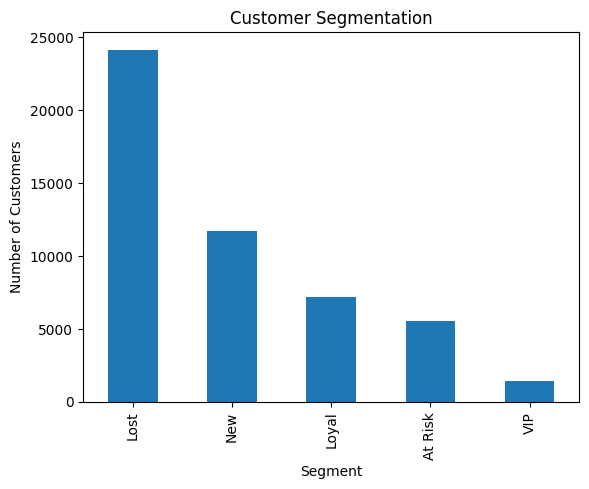

In [23]:
#VISUALIZATION
import matplotlib.pyplot as plt

# Create bar chart
segment_counts.plot(kind="bar")

# Add title and labels
plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

#Save chart
plt.savefig("C:/Users/salon/Downloads/CustomerSegmentationProject_MajorProject_SaloniRana/charts/customer_segmentation_bar.png", bbox_inches="tight")

# Show chart
plt.show()

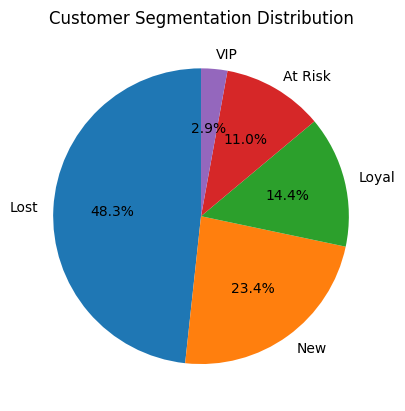

In [24]:
# PIE CHART FOR SEGMENT DISTRIBUTION
rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segmentation Distribution")
plt.ylabel("")  # Remove extra label

plt.savefig("C:/Users/salon/Downloads/CustomerSegmentationProject_MajorProject_SaloniRana/charts/customer_segmentation_pie.png", bbox_inches="tight")

plt.show()

In [29]:
# TOP 10 HIGH VALUE CUSTOMERS
top_customers = rfm.sort_values(by="Monetary", ascending=False).head(10)

top_customers

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer_ID,,,,,,,,
29440,29,42,5384778.37,4,5,5,455,Loyal
29276,82,30,4743264.92,2,5,5,255,At Risk
16071,99,32,4712165.97,1,5,5,155,At Risk
24275,36,40,4695690.91,3,5,5,355,Lost
27331,1,33,4661786.18,5,5,5,555,VIP
11818,18,30,4642948.49,4,5,5,455,Loyal
23599,42,29,4617708.15,3,5,5,355,Lost
12540,5,36,4559820.21,5,5,5,555,VIP
48403,13,38,4546022.19,5,5,5,555,VIP


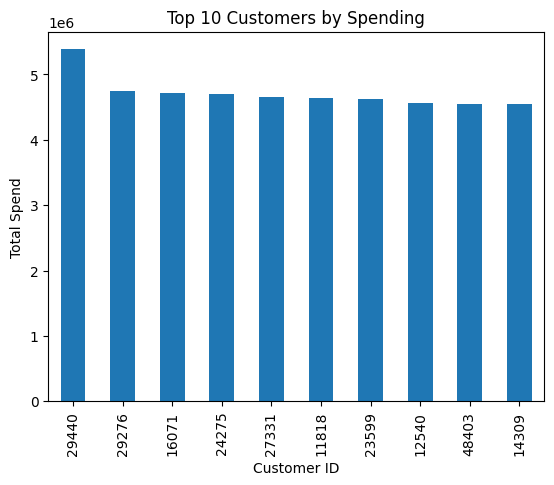

In [30]:
# Bar chart for top customers

top_customers["Monetary"].plot(kind="bar")

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend")
plt.savefig("C:/Users/salon/Downloads/CustomerSegmentationProject_MajorProject_SaloniRana/charts/top_10_customers.png", bbox_inches="tight")
plt.show()

In [31]:
# AT RISK CUSTOMERS

at_risk = rfm[rfm["Segment"] == "At Risk"]

at_risk.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer_ID,,,,,,,,
10004,73,30,2972122.18,2,5,5,255,At Risk
10006,185,23,2587439.89,1,4,5,145,At Risk
10015,95,26,2348695.25,2,5,4,254,At Risk
10022,147,25,3236073.04,1,5,5,155,At Risk
10029,72,23,1559379.99,2,4,2,242,At Risk


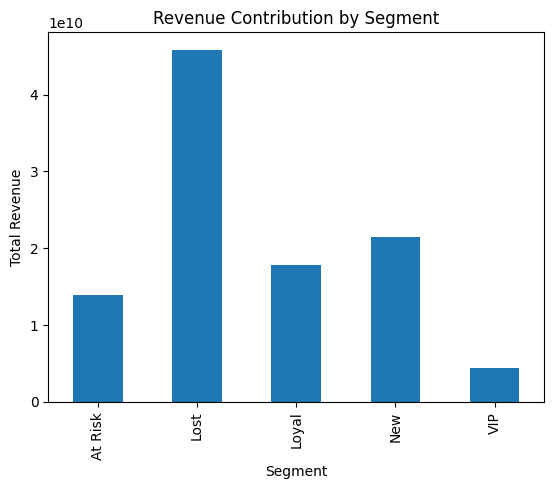

In [32]:
# REVENUE CONTRIBUTION BY SEGMENT

revenue_segment = rfm.groupby("Segment")["Monetary"].sum()

revenue_segment.plot(kind="bar")

plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.savefig("C:/Users/salon/Downloads/CustomerSegmentationProject_MajorProject_SaloniRana/charts/revenue_contribution.png", bbox_inches="tight")


plt.show()

In [34]:
rfm.to_csv("C:/Users/salon/Downloads/CustomerSegmentationProject_MajorProject_SaloniRana/dataset/rfm_customer_segments.csv")